In [1]:
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

DATASET_ROOT = Path('../dataset')
POSES_ROOT   = DATASET_ROOT / 'poses'
METADATA_DIR = DATASET_ROOT / 'metadata'
# Dossier de sortie DIFFERENT de l'original pour ne pas ecraser l'existant
AUG_ROOT     = DATASET_ROOT / 'augmented_tcn_normalized'

import sys
sys.path.insert(0, str(Path('../..').resolve()))
from src.signs import SIGNS_TARGET, SIGN_TO_IDX, NUM_CLASSES
TARGET_T     = 32

TARGET_COUNT          = 1291   # match OUI (majority class)
MAX_VARIANTS_PER_ORIG = 50     # cap per original instance

print(f'Classes: {NUM_CLASSES} | Target per class: {TARGET_COUNT} | Max variants/orig: {MAX_VARIANTS_PER_ORIG}')

Classes: 20 | Target per class: 1291 | Max variants/orig: 50


Total instances with poses: 5269

Class distribution:
sign
OUI         2318
NON         1184
APPELER      444
VITE         256
MANGER       215
AIDER        170
DORMIR        90
MARCHER       79
CHAUD         78
BOIRE         73
PLEURER       51
FROID         47
PEUR          39
ENCEINTE      39
SOUFFRIR      38
HOPITAL       38
TETE          36
MORT          36
MEDECIN       30
RESPIRER       8


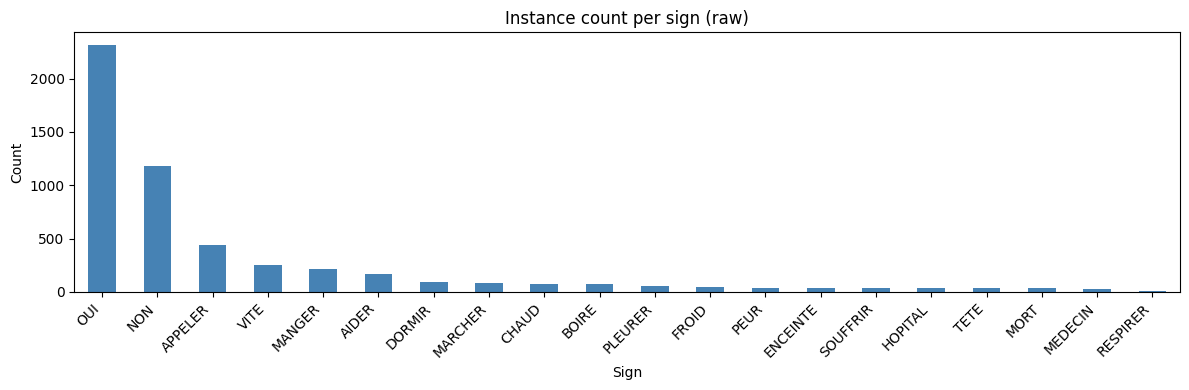

In [2]:
instances = pd.read_csv(DATASET_ROOT / 'instances.csv')
face_files = list((POSES_ROOT / 'face').glob('*.npy'))
available_ids = {f.stem for f in face_files}

df = instances[instances['id'].isin(available_ids)].copy()
df['label'] = df['sign'].map(SIGN_TO_IDX)
df = df[df['label'].notna()].copy()
df['label'] = df['label'].astype(int)

print(f'Total instances with poses: {len(df)}')
print('\nClass distribution:')
print(df['sign'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(12, 4))
df['sign'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Instance count per sign (raw)')
ax.set_xlabel('Sign')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [3]:
# Remove T=0 instances
lengths = {}
for _, row in df.iterrows():
    arr = np.load(POSES_ROOT / 'face' / f"{row['id']}.npy")
    lengths[row['id']] = arr.shape[0]
df['T'] = df['id'].map(lengths)
df_clean = df[df['T'] > 0].reset_index(drop=True)
print(f'Removed {len(df) - len(df_clean)} instances with T=0')
print(f'Remaining: {len(df_clean)}')

# Load official splits
with open(METADATA_DIR / 'splits' / 'train.json') as f:
    train_ids = set(json.load(f))
with open(METADATA_DIR / 'splits' / 'test.json') as f:
    test_ids = set(json.load(f))

df_train = df_clean[df_clean['id'].isin(train_ids)].reset_index(drop=True)
df_test  = df_clean[df_clean['id'].isin(test_ids)].reset_index(drop=True)

print(f'\nTrain: {len(df_train)} | Test: {len(df_test)}')
print('\nTrain class distribution:')
print(df_train['sign'].value_counts().to_string())

Removed 35 instances with T=0
Remaining: 5234

Train: 2874 | Test: 2360

Train class distribution:
sign
OUI         1291
NON          599
APPELER      221
VITE         137
AIDER        116
MANGER       115
CHAUD         55
DORMIR        51
BOIRE         49
MARCHER       40
PLEURER       30
FROID         25
ENCEINTE      25
MORT          24
TETE          22
SOUFFRIR      21
PEUR          20
HOPITAL       19
MEDECIN        9
RESPIRER       5


In [4]:
def resample_sequence(arr: np.ndarray, target_T: int) -> np.ndarray:
    T = arr.shape[0]
    if T == 0:
        raise ValueError(f'resample_sequence received empty array (shape {arr.shape})')
    if T == target_T:
        return arr
    idx = np.linspace(0, T - 1, target_T)
    lo  = np.floor(idx).astype(int).clip(0, T - 1)
    hi  = np.ceil(idx).astype(int).clip(0, T - 1)
    a   = (idx - lo)[:, None, None]
    return ((1 - a) * arr[lo] + a * arr[hi]).astype(np.float32)


def load_raw_poses(instance_id: str):
    body  = np.load(POSES_ROOT / 'pose'       / f'{instance_id}.npy').astype(np.float32)
    lhand = np.load(POSES_ROOT / 'left_hand'  / f'{instance_id}.npy').astype(np.float32)
    rhand = np.load(POSES_ROOT / 'right_hand' / f'{instance_id}.npy').astype(np.float32)
    return body, lhand, rhand


_sid = df_train['id'].iloc[0]
_b, _l, _r = load_raw_poses(_sid)
assert _b.ndim == 3 and _b.shape[2] == 3
assert _b.shape[1] == 33 and _l.shape[1] == 21 and _r.shape[1] == 21
_r32 = resample_sequence(_b, 32)
assert _r32.shape[0] == 32
print(f'load_raw_poses OK: body={_b.shape}, lhand={_l.shape}, rhand={_r.shape}')
print(f'resample_sequence OK: {_b.shape} -> {_r32.shape}')

load_raw_poses OK: body=(7, 33, 3), lhand=(7, 21, 3), rhand=(7, 21, 3)
resample_sequence OK: (7, 33, 3) -> (32, 33, 3)


In [5]:
def aug_horizontal_flip(body, lhand, rhand):
    def flip_x(arr):
        arr = arr.copy()
        arr[:, :, 0] = 1.0 - arr[:, :, 0]
        return arr
    return flip_x(body), flip_x(rhand), flip_x(lhand)


def aug_temporal_flip(body, lhand, rhand):
    return body[::-1].copy(), lhand[::-1].copy(), rhand[::-1].copy()


def aug_global_translation(body, lhand, rhand, dx: float, dy: float):
    def shift(arr):
        arr = arr.copy()
        arr[:, :, 0] = np.clip(arr[:, :, 0] + dx, 0.0, 1.0)
        arr[:, :, 1] = np.clip(arr[:, :, 1] + dy, 0.0, 1.0)
        return arr
    return shift(body), shift(lhand), shift(rhand)


def aug_global_scaling(body, lhand, rhand, scale: float):
    all_x = np.concatenate([body[:, :, 0].ravel(), lhand[:, :, 0].ravel(), rhand[:, :, 0].ravel()])
    all_y = np.concatenate([body[:, :, 1].ravel(), lhand[:, :, 1].ravel(), rhand[:, :, 1].ravel()])
    cx, cy = all_x.mean(), all_y.mean()
    def scale_arr(arr):
        arr = arr.copy()
        arr[:, :, 0] = np.clip((arr[:, :, 0] - cx) * scale + cx, 0.0, 1.0)
        arr[:, :, 1] = np.clip((arr[:, :, 1] - cy) * scale + cy, 0.0, 1.0)
        return arr
    return scale_arr(body), scale_arr(lhand), scale_arr(rhand)


def aug_global_rotation(body, lhand, rhand, angle_deg: float):
    theta = np.radians(angle_deg)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    all_x = np.concatenate([body[:, :, 0].ravel(), lhand[:, :, 0].ravel(), rhand[:, :, 0].ravel()])
    all_y = np.concatenate([body[:, :, 1].ravel(), lhand[:, :, 1].ravel(), rhand[:, :, 1].ravel()])
    cx, cy = all_x.mean(), all_y.mean()
    def rotate_arr(arr):
        arr = arr.copy()
        x = arr[:, :, 0] - cx
        y = arr[:, :, 1] - cy
        arr[:, :, 0] = np.clip(cos_t * x - sin_t * y + cx, 0.0, 1.0)
        arr[:, :, 1] = np.clip(sin_t * x + cos_t * y + cy, 0.0, 1.0)
        return arr
    return rotate_arr(body), rotate_arr(lhand), rotate_arr(rhand)


def aug_speed_perturbation(body, lhand, rhand, factor: float):
    T = body.shape[0]
    new_T = max(1, int(round(T * factor)))
    idx = np.linspace(0, T - 1, new_T)
    lo  = np.floor(idx).astype(int).clip(0, T - 1)
    hi  = np.ceil(idx).astype(int).clip(0, T - 1)
    a   = (idx - lo)[:, None, None]
    interp = lambda arr: ((1 - a) * arr[lo] + a * arr[hi]).astype(np.float32)
    return interp(body), interp(lhand), interp(rhand)


_b, _l, _r = load_raw_poses(df_train['id'].iloc[0])
_bf, _lf, _rf = aug_horizontal_flip(_b, _l, _r)
assert _bf.shape == _b.shape and np.all(_bf[:, :, 0] == 1.0 - _b[:, :, 0])
_bt, _lt, _rt = aug_temporal_flip(_b, _l, _r)
assert np.allclose(_bt[0], _b[-1])
_bs, _ls, _rs = aug_speed_perturbation(_b, _l, _r, 1.2)
assert _bs.shape[0] == max(1, int(round(_b.shape[0] * 1.2)))
print('All augmentation functions OK')

All augmentation functions OK


In [6]:
# ── Normalisation corps-relative ──────────────────────────────────────────────
# Pourquoi : le modele entraine sur des coordonnees absolues [0,1] collapse sur
# une seule classe quand la webcam capture le signataire a une position/distance
# differente des videos LSFB.
#
# Solution : centrer sur le milieu des epaules (landmarks 11 et 12 de la pose),
# normaliser par la distance inter-epaules. Les coordonnees deviennent
# invariantes a la position et a l'echelle dans le cadre.
#
# Layout vecteur (225,) par frame :
#   indices  0-98  : pose (33 landmarks x 3)
#   indices 99-161 : left_hand (21 x 3)
#   indices 162-224: right_hand (21 x 3)
# landmark 11 (epaule gauche)  -> row 33 (x), 34 (y), 35 (z)
# landmark 12 (epaule droite)  -> row 36 (x), 37 (y), 38 (z)

def normalize_body_relative_sequence(coords: np.ndarray) -> np.ndarray:
    """
    Normalise une sequence (225, T) frame par frame.
    cx, cy = milieu des epaules ; scale = distance inter-epaules (plan xy).
    x_norm = (x - cx) / scale,  y_norm = (y - cy) / scale,  z_norm = z / scale.
    Frames sans pose detectee sont laissees telles quelles.
    """
    result = coords.copy()  # (225, T)

    sl_x = coords[33, :]  # epaule gauche x  (T,)
    sl_y = coords[34, :]  # epaule gauche y
    sr_x = coords[36, :]  # epaule droite x
    sr_y = coords[37, :]  # epaule droite y

    cx    = (sl_x + sr_x) / 2.0
    cy    = (sl_y + sr_y) / 2.0
    scale = np.sqrt((sl_x - sr_x) ** 2 + (sl_y - sr_y) ** 2)  # (T,)

    valid = (scale > 1e-6) & ~((sl_x == 0) & (sl_y == 0) & (sr_x == 0) & (sr_y == 0))
    scale_safe = np.where(valid, scale, 1.0)

    # coords[0::3,:] -> toutes les x (shape 75, T) ; broadcasting avec (1, T)
    result[0::3, :] = (coords[0::3, :] - cx[np.newaxis, :]) / scale_safe[np.newaxis, :]
    result[1::3, :] = (coords[1::3, :] - cy[np.newaxis, :]) / scale_safe[np.newaxis, :]
    result[2::3, :] =  coords[2::3, :]                       / scale_safe[np.newaxis, :]

    result[:, ~valid] = coords[:, ~valid]  # frames invalides : pas de normalisation
    return result.astype(np.float32)


# Sanity check
_b, _l, _r = load_raw_poses(df_train['id'].iloc[0])
_b32 = resample_sequence(_b, TARGET_T)
_l32 = resample_sequence(_l, TARGET_T)
_r32 = resample_sequence(_r, TARGET_T)
_flat = np.concatenate([
    _b32.reshape(TARGET_T, -1),
    _l32.reshape(TARGET_T, -1),
    _r32.reshape(TARGET_T, -1)
], axis=1).T  # (225, 32)
_norm = normalize_body_relative_sequence(_flat)
assert _norm.shape == (225, TARGET_T)
print(f'normalize_body_relative_sequence OK')
print(f'  avant normalisation : mean={_flat.mean():.3f}, std={_flat.std():.3f}, range=[{_flat.min():.3f}, {_flat.max():.3f}]')
print(f'  apres normalisation : mean={_norm.mean():.3f}, std={_norm.std():.3f}, range=[{_norm.min():.3f}, {_norm.max():.3f}]')

normalize_body_relative_sequence OK
  avant normalisation : mean=0.349, std=0.476, range=[-1.016, 1.717]
  apres normalisation : mean=0.298, std=1.502, range=[-4.396, 5.645]


In [7]:
def poses_to_coords(body, lhand, rhand, target_T: int = TARGET_T) -> np.ndarray:
    """
    Resample, flatten et normalise les poses brutes en (225, target_T).
    La normalisation corps-relative est appliquee en derniere etape.
    """
    body  = resample_sequence(body,  target_T)  # (target_T, 33, 3)
    lhand = resample_sequence(lhand, target_T)  # (target_T, 21, 3)
    rhand = resample_sequence(rhand, target_T)  # (target_T, 21, 3)

    body_flat  = body.reshape(target_T, -1)   # (target_T, 99)
    lhand_flat = lhand.reshape(target_T, -1)  # (target_T, 63)
    rhand_flat = rhand.reshape(target_T, -1)  # (target_T, 63)

    coords = np.concatenate([body_flat, lhand_flat, rhand_flat], axis=1)  # (target_T, 225)
    coords = coords.T.astype(np.float32)  # (225, target_T)

    # Normalisation corps-relative
    coords = normalize_body_relative_sequence(coords)
    return coords


_b, _l, _r = load_raw_poses(df_train['id'].iloc[0])
_coords = poses_to_coords(_b, _l, _r)
assert _coords.shape == (225, TARGET_T)
assert _coords.dtype == np.float32
print(f'poses_to_coords OK: shape={_coords.shape}, range=[{_coords.min():.3f}, {_coords.max():.3f}]')

poses_to_coords OK: shape=(225, 32), range=[-4.396, 5.645]


In [8]:
COMBINATIONS = [
    'hflip',
    'tflip',
    'translate',
    'scale',
    'rotate',
    'speed',
    'hflip+translate',
    'hflip+scale',
    'hflip+rotate',
    'tflip+speed',
    'translate+scale+rotate',
    'hflip+tflip+translate',
]


def apply_combo(body, lhand, rhand, combo: str):
    b, l, r = body, lhand, rhand
    if 'hflip' in combo:
        b, l, r = aug_horizontal_flip(b, l, r)
    if 'tflip' in combo:
        b, l, r = aug_temporal_flip(b, l, r)
    if 'translate' in combo:
        dx = np.random.uniform(-0.1, 0.1)
        dy = np.random.uniform(-0.1, 0.1)
        b, l, r = aug_global_translation(b, l, r, dx, dy)
    if 'scale' in combo:
        s = np.random.uniform(0.9, 1.1)
        b, l, r = aug_global_scaling(b, l, r, s)
    if 'rotate' in combo:
        angle = np.random.uniform(-5.0, 5.0)
        b, l, r = aug_global_rotation(b, l, r, angle)
    if 'speed' in combo:
        factor = np.random.uniform(0.8, 1.2)
        b, l, r = aug_speed_perturbation(b, l, r, factor)
    return b, l, r


_b, _l, _r = load_raw_poses(df_train['id'].iloc[0])
for _combo in COMBINATIONS:
    _ab, _al, _ar = apply_combo(_b, _l, _r, _combo)
    _coords = poses_to_coords(_ab, _al, _ar)
    assert _coords.shape == (225, TARGET_T), f"Combo '{_combo}' produced shape {_coords.shape}"
print(f'apply_combo OK for all {len(COMBINATIONS)} combinations')

apply_combo OK for all 12 combinations


In [9]:
(AUG_ROOT / 'npy').mkdir(parents=True, exist_ok=True)

records = []

np.random.seed(42)

for sign in tqdm(SIGNS_TARGET, desc='Signs'):
    sign_df    = df_train[df_train['sign'] == sign].reset_index(drop=True)
    label      = SIGN_TO_IDX[sign]
    n_orig     = len(sign_df)
    n_needed   = max(0, TARGET_COUNT - n_orig)

    for _, row in sign_df.iterrows():
        b, l, r = load_raw_poses(row['id'])
        coords  = poses_to_coords(b, l, r)
        fname   = f"{row['id']}_orig"
        np.save(AUG_ROOT / 'npy' / f'{fname}.npy', coords)
        records.append({'id': fname, 'sign': sign, 'label': label,
                        'source_id': row['id'], 'aug_type': 'original'})

    if n_needed == 0:
        continue

    aug_count   = 0
    combo_cycle = 0

    while aug_count < n_needed:
        for _, row in sign_df.iterrows():
            if aug_count >= n_needed:
                break
            b, l, r  = load_raw_poses(row['id'])
            combo    = COMBINATIONS[combo_cycle % len(COMBINATIONS)]
            ab, al, ar = apply_combo(b, l, r, combo)
            coords   = poses_to_coords(ab, al, ar)
            fname    = f"{row['id']}_aug{aug_count:04d}"
            np.save(AUG_ROOT / 'npy' / f'{fname}.npy', coords)
            records.append({'id': fname, 'sign': sign, 'label': label,
                            'source_id': row['id'], 'aug_type': combo})
            aug_count  += 1
            combo_cycle += 1

print(f'\nTotal records: {len(records)}')

Signs:   0%|          | 0/20 [00:00<?, ?it/s]


Total records: 25820


In [10]:
df_meta = pd.DataFrame(records)
df_meta.to_csv(AUG_ROOT / 'metadata.csv', index=False)

with open(AUG_ROOT / 'sign_to_idx.json', 'w') as f:
    json.dump(SIGN_TO_IDX, f, indent=2)

print('Saved:')
print(f"  metadata.csv     -- {len(df_meta)} rows")
print(f"  sign_to_idx.json")
print(f"  npy/             -- {len(list((AUG_ROOT / 'npy').glob('*.npy')))} files")

Saved:
  metadata.csv     -- 25820 rows
  sign_to_idx.json
  npy/             -- 25820 files


Shape sanity: OK
Final class counts (augmented train normalise):
sign
OUI         1291
NON         1291
APPELER     1291
VITE        1291
MANGER      1291
AIDER       1291
BOIRE       1291
MARCHER     1291
CHAUD       1291
DORMIR      1291
RESPIRER    1291
PLEURER     1291
FROID       1291
PEUR        1291
ENCEINTE    1291
HOPITAL     1291
SOUFFRIR    1291
TETE        1291
MORT        1291
MEDECIN     1291


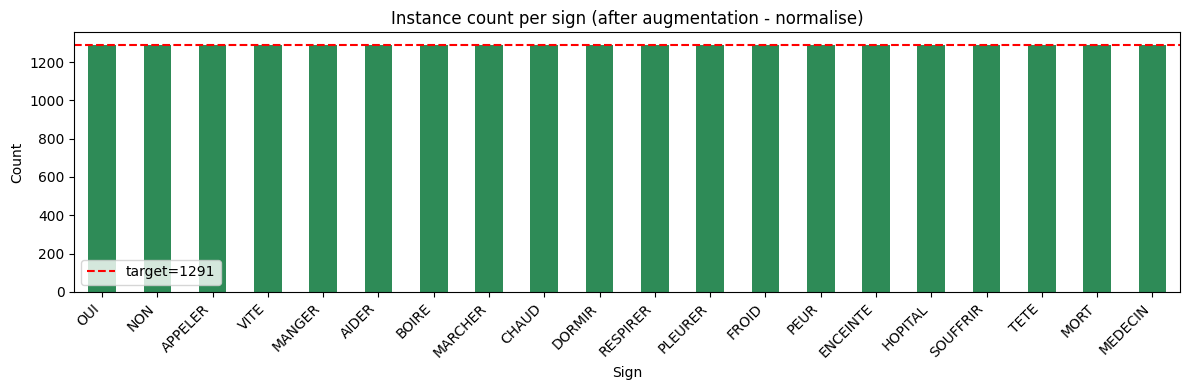

In [11]:
import random
npy_files = list((AUG_ROOT / 'npy').glob('*.npy'))
random.seed(42)
for f in random.sample(npy_files, min(5, len(npy_files))):
    arr = np.load(f)
    assert arr.shape == (225, TARGET_T), f"{f.name}: expected (225,{TARGET_T}), got {arr.shape}"
    assert arr.dtype == np.float32,       f"{f.name}: expected float32, got {arr.dtype}"
print('Shape sanity: OK')

counts_aug = df_meta.groupby('sign').size().reindex(SIGNS_TARGET)
print('Final class counts (augmented train normalise):')
print(counts_aug.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
counts_aug.plot(kind='bar', ax=ax, color='seagreen')
ax.axhline(TARGET_COUNT, color='red', linestyle='--', label=f'target={TARGET_COUNT}')
ax.set_title('Instance count per sign (after augmentation - normalise)')
ax.set_xlabel('Sign')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()